In [104]:
%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [105]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

sys.path.append('../src')

from data_pipeline import load_all_raw_data
from data_analysis import (
    filter_data_until_date, temporal_split_data, 
    plot_user_analysis, plot_temporal_analysis, 
    plot_station_analysis, plot_activity_heatmap, 
    print_summary_statistics
)
from preprocess import (
    analyze_users_for_visualization, 
    analyze_trips_for_visualization,
    clean_dataset_comprehensive,
    clean_coordinate_columns,
    optimize_memory_usage,
    preprocess_data
)


In [106]:

raw_data_dir = Path('../data/raw')
save_dir = Path('../data/raw/combined')

users_df, trips_df = load_all_raw_data(raw_data_dir, save_dir)

print(f"Datos cargados: {len(users_df):,} usuarios, {len(trips_df):,} viajes")


Datos cargados: 627,883 usuarios, 14,380,108 viajes


In [107]:
print("🔍 ORIGINAL RAW DATA NaN ANALYSIS (BEFORE PREPROCESSING)")
print("=" * 60)

print("Number of null values per column (ORIGINAL):")
nan_counts_original = trips_df.isnull().sum()
print(nan_counts_original)

print("\nPercentage of null values per column (ORIGINAL):")
nan_percentages_original = (trips_df.isnull().sum() / len(trips_df) * 100).round(2)
print(nan_percentages_original)

print(f"\nOriginal dataset shape: {trips_df.shape}")
print(f"Original columns: {list(trips_df.columns)}")


key_cols = ['id_recorrido', 'id_estacion_origen', 'id_estacion_destino', 'id_usuario', 'duracion_recorrido', 'genero']




🔍 ORIGINAL RAW DATA NaN ANALYSIS (BEFORE PREPROCESSING)
Number of null values per column (ORIGINAL):
id_recorrido                      0
duracion_recorrido              270
fecha_origen_recorrido            0
id_estacion_origen                0
nombre_estacion_origen            0
direccion_estacion_origen         0
long_estacion_origen              0
lat_estacion_origen               0
fecha_destino_recorrido        3379
id_estacion_destino              43
nombre_estacion_destino          43
direccion_estacion_destino       43
long_estacion_destino            43
lat_estacion_destino             43
id_usuario                        0
modelo_bicicleta                  0
genero                        76061
dtype: int64

Percentage of null values per column (ORIGINAL):
id_recorrido                  0.00
duracion_recorrido            0.00
fecha_origen_recorrido        0.00
id_estacion_origen            0.00
nombre_estacion_origen        0.00
direccion_estacion_origen     0.00
long_estacion_

In [108]:

users_df, trips_df = preprocess_data(users_df, trips_df, verbose=True)


STARTING COMPLETE PREPROCESSING PIPELINE
Initial state:
  - Users: 627,883 rows, 5 columns
  - Trips: 14,380,108 rows, 17 columns

1. Final comprehensive cleaning...
Final comprehensive cleaning for 14,380,108 rows...
Final cleaning completed for 14,380,108 rows!
Final comprehensive cleaning for 627,883 rows...
Final cleaning completed for 627,883 rows!

2. Geographic coordinates cleaning...
Batch coordinate cleaning
Processing 14,380,108 rows...
Cleaning coordinate column: lat_estacion_destino
Original nulls: 43
Valid coordinates: 14,380,065
Final nulls: 43
Sample cleaned values: [-34.611032, -34.611032, -34.611032, -34.601822, -34.606498]
Cleaning coordinate column: long_estacion_destino
Original nulls: 43
Valid coordinates: 14,380,065
Final nulls: 43
Sample cleaned values: [-58.3682604, -58.3682604, -58.3682604, -58.368781, -58.381098]
Cleaning coordinate column: lat_estacion_origen
Original nulls: 0
Valid coordinates: 14,380,108
Final nulls: 0
Sample cleaned values: [-34.599068, -3

In [109]:

# ensure datetime types are correct before filtering
print(f"Final verification before filtering:")
print(f"  - users_df['fecha_alta']: {users_df['fecha_alta'].dtype}")
print(f"  - trips_df['fecha_origen_recorrido']: {trips_df['fecha_origen_recorrido'].dtype}")

print(f"\n5. Temporal filtering...")
users_filtered, trips_filtered = filter_data_until_date(
    users_df, trips_df, 
    max_date="2024-08-31",
    verbose=True
)

print(f"\n6. Temporal split...")
data_splits = temporal_split_data(
    users_filtered, trips_filtered,
    train_end_date="2023-06-30",  # Train until jun 2023
    val_end_date="2023-12-31",    # Val jul-dec 2023  
    test_end_date="2024-08-31",   # Test jan-aug 2024
    verbose=True
)

users_train = data_splits['users_train']
users_val = data_splits['users_val'] 
users_test = data_splits['users_test']

trips_train = data_splits['trips_train']
trips_val = data_splits['trips_val']
trips_test = data_splits['trips_test']

print(f"\nOptimized preprocessing completed!")
print(f"Users: Train={len(users_train):,}, Val={len(users_val):,}, Test={len(users_test):,}")
print(f"Trips: Train={len(trips_train):,}, Val={len(trips_val):,}, Test={len(trips_test):,}")
print(f"Final columns: {list(trips_train.columns)}")


Final verification before filtering:
  - users_df['fecha_alta']: datetime64[ns]
  - trips_df['fecha_origen_recorrido']: datetime64[ns]

5. Temporal filtering...
FILTERING DATA UNTIL 2024-08-31
   Input: Users=627,883, Trips=14,380,108
   Filtering users...
   Filtering trips...
   Users: 627,883 → 546,010 (-81,873)
   Trips: 14,380,108 → 12,976,053 (-1,404,055)

6. Temporal split...
OPTIMIZED TEMPORAL SPLIT
   Train ≤ 2023-06-30 | Val: 2023-06-30 - 2023-12-31 | Test: 2023-12-31 - 2024-08-31
   Input: Users=546,010, Trips=12,976,053
   Splitting users...
   Splitting trips...
   Users: Train=346,517, Val=84,289, Test=115,204
   Trips: Train=9,505,149, Val=1,312,801, Test=2,158,103

Optimized preprocessing completed!
Users: Train=346,517, Val=84,289, Test=115,204
Trips: Train=9,505,149, Val=1,312,801, Test=2,158,103
Final columns: ['id_recorrido', 'duracion_recorrido', 'fecha_origen_recorrido', 'id_estacion_origen', 'nombre_estacion_origen', 'direccion_estacion_origen', 'long_estacion_or


Estadísticas de entrenamiento:
Usuarios en train: (346517, 5)
Viajes en train: (9505149, 17)

Generando análisis de usuarios...


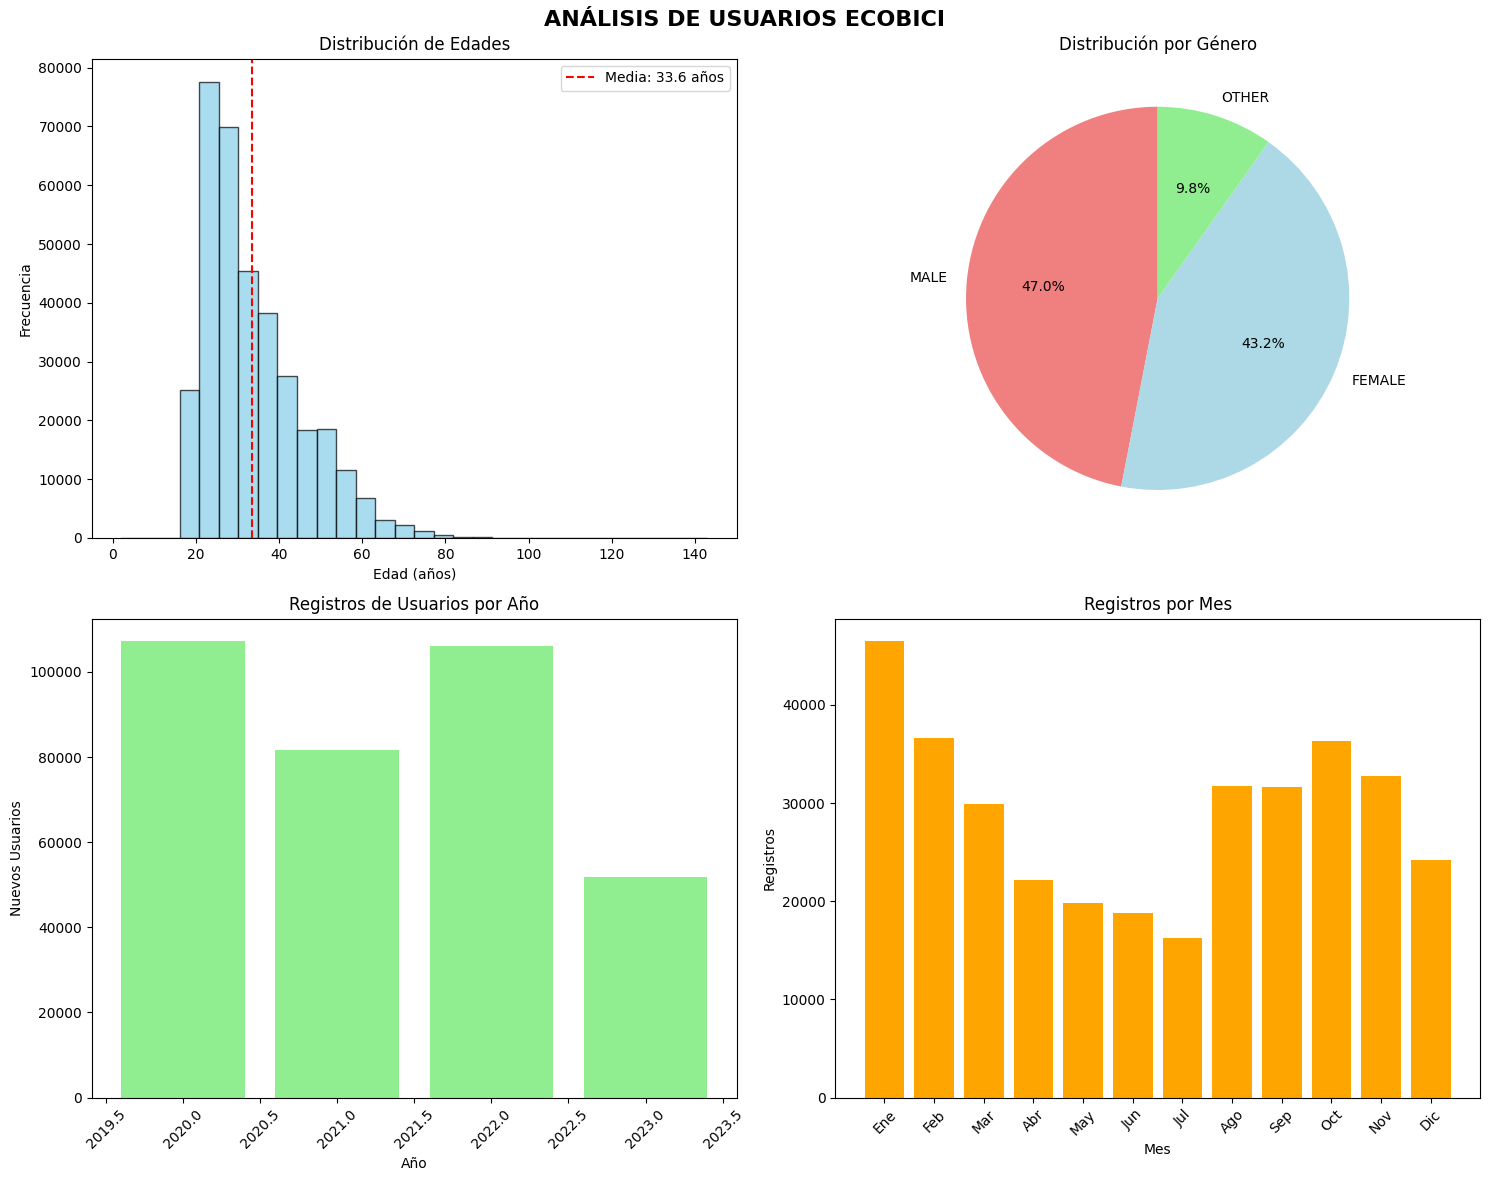

Generando análisis temporal...


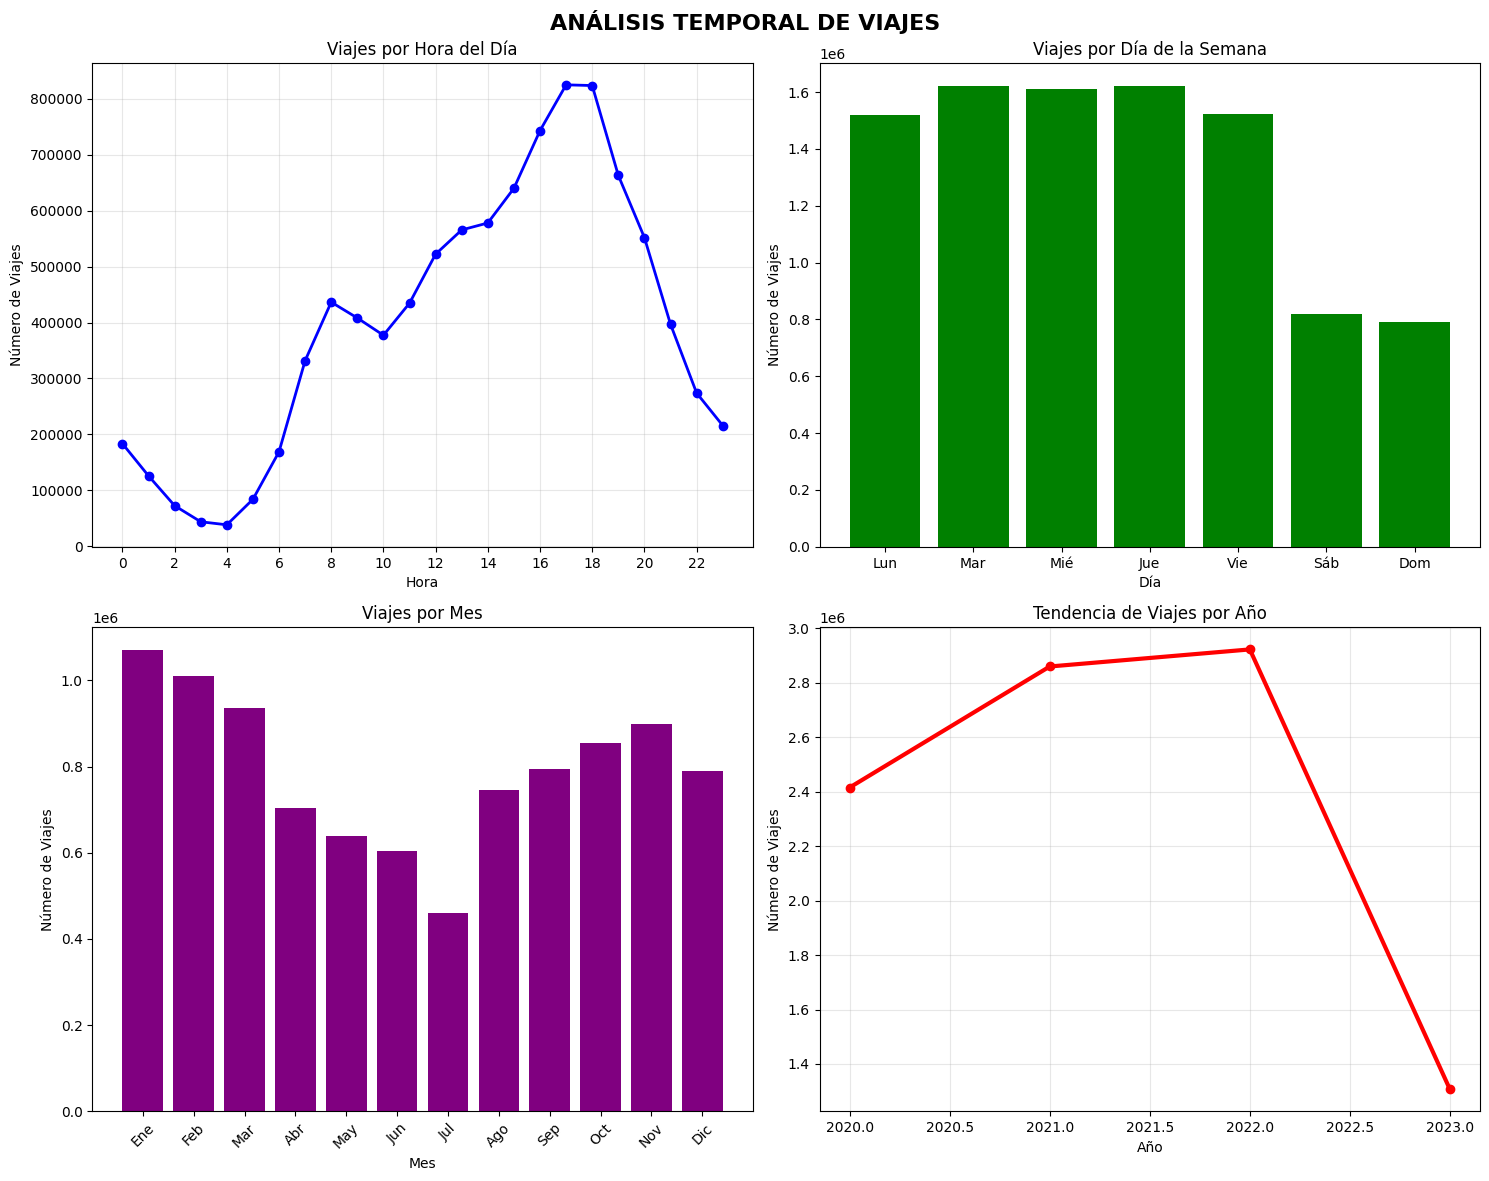

Generando análisis de estaciones...


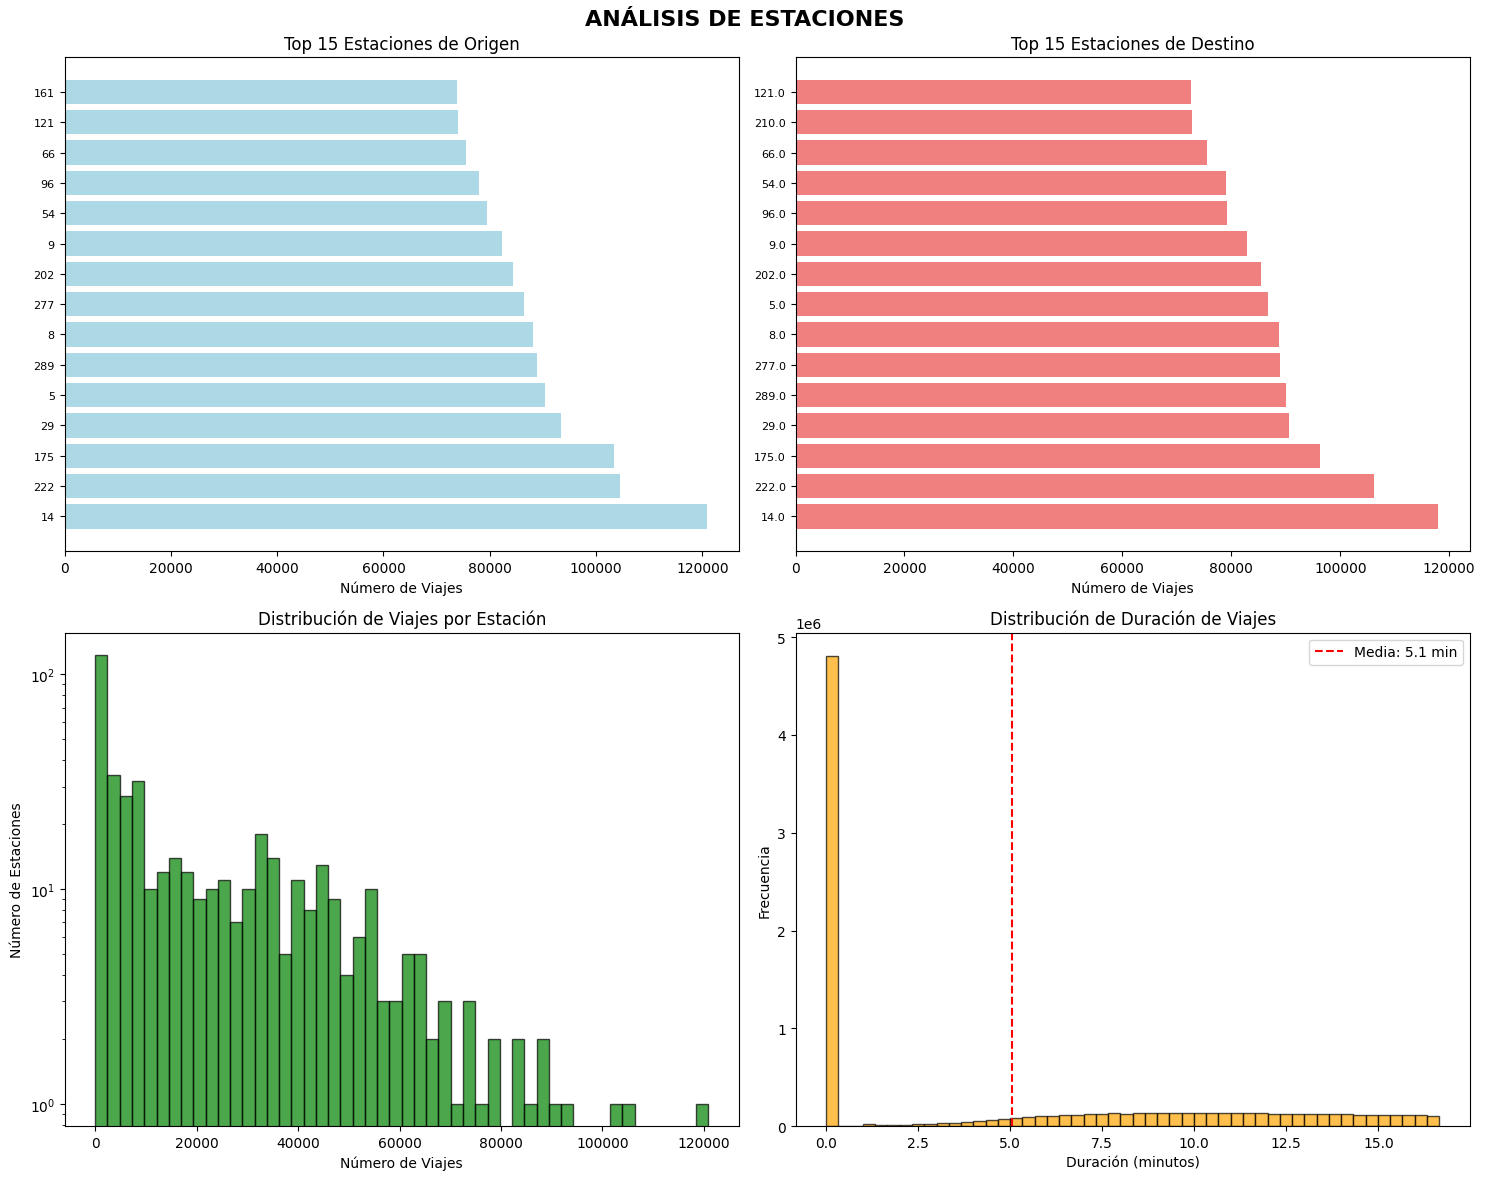

Generando heatmap de actividad...


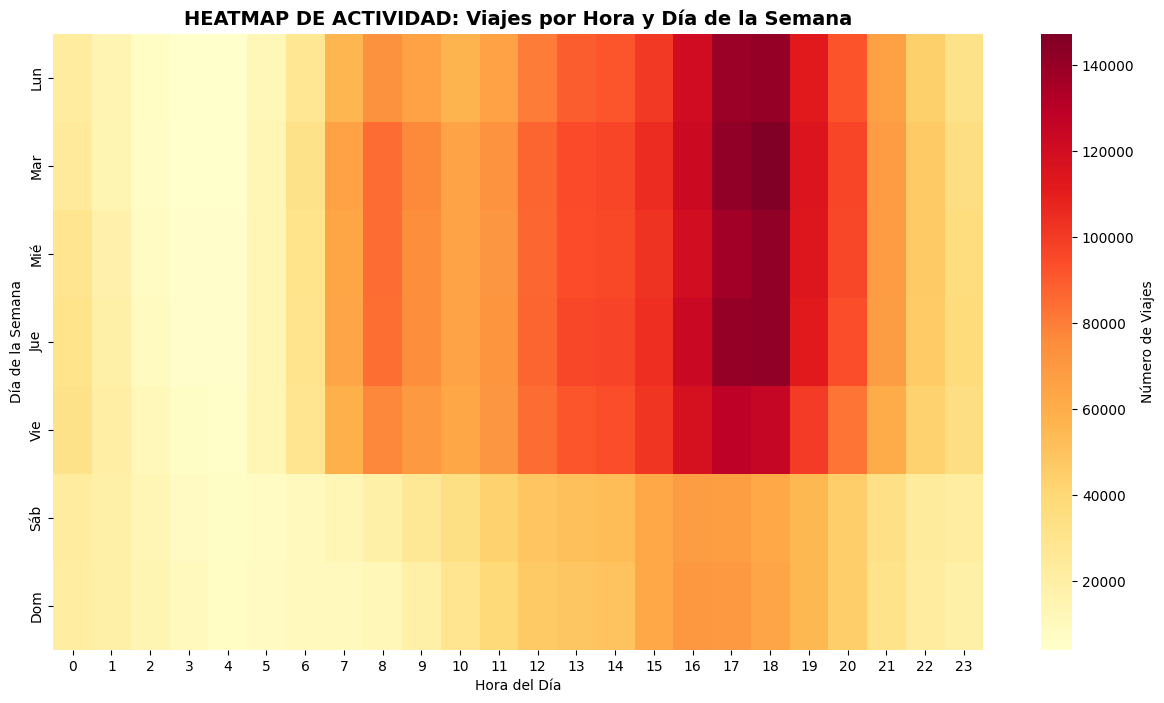


ESTADÍSTICAS RESUMEN
USUARIOS:
   • Total usuarios: 546,010
   • Edad promedio: 33.6 años
   • Distribución de género:
     - MALE: 162,712 (29.8%)
     - FEMALE: 149,785 (27.4%)
     - OTHER: 34,018 (6.2%)

VIAJES:
   • Total viajes: 12,976,053
   • Período: 2020-01-01 00:00:08 - 2023-06-29 23:59:55
   • Promedio viajes/día: 10,169
   • Estaciones únicas (origen): 447
   • Estaciones únicas (destino): 15
   • Duración promedio: 5.1 minutos


In [110]:


processed_users = analyze_users_for_visualization(users_train)
processed_trips = analyze_trips_for_visualization(trips_train)



print(f"\nEstadísticas de entrenamiento:")
print(f"Usuarios en train: {users_train.shape}")
print(f"Viajes en train: {trips_train.shape}")

print("\nGenerando análisis de usuarios...")
plot_user_analysis(processed_users, save_plots=False, output_dir=None)

print("Generando análisis temporal...")
plot_temporal_analysis(processed_trips, save_plots=False, output_dir=None)

print("Generando análisis de estaciones...")
plot_station_analysis(processed_trips, save_plots=False, output_dir=None)

print("Generando heatmap de actividad...")
plot_activity_heatmap(processed_trips, save_plots=False, output_dir=None)

print_summary_statistics(users_filtered, processed_users, trips_filtered, processed_trips)


In [112]:
trips_df.head()

,id_recorrido,duracion_recorrido,fecha_origen_recorrido,id_estacion_origen,nombre_estacion_origen,direccion_estacion_origen,long_estacion_origen,lat_estacion_origen,fecha_destino_recorrido,id_estacion_destino,nombre_estacion_destino,direccion_estacion_destino,long_estacion_destino,lat_estacion_destino,id_usuario,modelo_bicicleta,genero
0,7210548,1.582,2020-01-24 21:54:39,27,027 - Montevideo,Cordoba Av. & Montevideo,-58.390087,-34.599068,2020-01-24 22:21:01,3.0,003 - ADUANA,Moreno & Av Paseo Colon,-58.368259,-34.611031,192009.0,ICONIC,FEMALE
1,7199093,204.000,2020-01-24 07:04:19,151,151 - AIME PAINÉ,"Villaflor, Azucena & Paine, Aime",-58.361286,-34.611816,2020-01-24 07:07:43,3.0,003 - ADUANA,Moreno & Av Paseo Colon,-58.368259,-34.611031,36380.0,ICONIC,MALE
2,7196805,1.790,2020-01-24 00:15:17,111,111 - MACACHA GUEMES,Machaca Guemes 350,-58.364685,-34.605488,2020-01-24 00:45:07,3.0,003 - ADUANA,Moreno & Av Paseo Colon,-58.368259,-34.611031,460080.0,ICONIC,MALE
3,7203598,10.688,2020-01-24 12:38:16,285,400 - Reserva Ecologica,"Achaval Rodriguez, T., Dr. Av. 1520",-58.356174,-34.617210,2020-01-24 15:36:24,4.0,004 - Plaza Roma,Lavalle & Bouchard,-58.368782,-34.601822,3857.0,ICONIC,MALE
4,7200335,673.000,2020-01-24 08:31:01,171,171 - Pasteur,519 Pasteur,-58.399754,-34.603283,2020-01-24 08:42:14,7.0,007 - OBELISCO,CARLOS PELEGRINI 215,-58.381100,-34.606499,391034.0,ICONIC,FEMALE
